In [6]:
# ==============================================================================
# PROJETO 3: SEGMENTAÇÃO DE CLIENTES (MARKETING BANCÁRIO)
# ETAPA 1: CRIAR A BASE DE DADOS DOS CLIENTES DO BANCO - CORRIGIDO
# ==============================================================================
# Aqui chamamos os nossos "ajudantes" padrão do Python para mexer com tabelas e números.
import pandas as pd
import numpy as np

# Definimos uma "semente" (seed). Isso garante que toda vez que o código rodar,
# ele vai gerar exatamente os mesmos números aleatórios, sem mudar o resultado.
np.random.seed(42)

# O nosso banco fictício terá uma base de 1.500 clientes ativos para analisarmos.
n_clientes = 1500

# ------------------------------------------------------------------------------
# EXPLICAÇÃO PARA LEIGOS: Como os clientes se comportam no mundo real?
# Vamos misturar na tabela 3 tipos de perfis de pessoas para ver se a IA descobre sozinha:
# Perfil 1: Jovens/Universitários -> Ganham pouco, score médio, quase não investem.
# Perfil 2: Classe Média -> Ganham bem, score bom, guardam um dinheiro em investimentos.
# Perfil 3: Clientes VIP -> Ganham muito, score excelente, têm muito dinheiro investido.
# ------------------------------------------------------------------------------

# Sorteamos qual perfil cada um dos 1.500 clientes vai ter (40% jovens, 40% classe média, 20% VIP)
grupo = np.random.choice([1, 2, 3], size=n_clientes, p=[0.4, 0.4, 0.2])

# Criamos listas vazias para guardar as informações de cada um
renda = []
score = []
investimento = []

# Passamos cliente por cliente aplicando as características do perfil dele
for g in grupo:
    if g == 1:  # Se for do grupo de Jovens/Universitários:
        renda.append(np.random.randint(18000, 45000))      # Renda anual entre R$ 18k e R$ 45k
        score.append(np.random.randint(350, 600))          # Score do Serasa mais baixo
        investimento.append(np.random.randint(0, 5000))    # Pouco ou nenhum investimento
    elif g == 2:  # Se for do grupo de Classe Média:
        renda.append(np.random.randint(45000, 90000))      # Renda anual entre R$ 45k e R$ 90k
        score.append(np.random.randint(600, 800))          # Score bom
        investimento.append(np.random.randint(5000, 40000)) # Investimento moderado
    else:  # Se for do grupo de Clientes VIP (Alta Renda):
        renda.append(np.random.randint(90000, 250000))      # Renda anual de R$ 90k até R$ 250k
        score.append(np.random.randint(700, 1000))         # Score excelente
        investimento.append(np.random.randint(40000, 150000)) # Muito dinheiro investido

# Juntamos todas essas listas numa estrutura de dicionário (como se fossem as colunas do Excel)
dados_marketing = {
    'id_cliente': range(800001, 800001 + n_clientes), # Cria uma identificação para cada cliente (ex: 800001, 800002...)
    'renda_anual': renda,
    'score_credito': score,
    'total_investido': investimento
}

# Transformamos tudo isso numa tabela bonitinha do Pandas (DataFrame)
df_marketing = pd.DataFrame(dados_marketing)

# ------------------------------------------------------------------------------
# TOQUE DE REALIDADE: No mundo real, os dados não são perfeitos.
# Adicionamos uma pequena variação nos números (ruído) para que os grupos fiquem levemente
# misturados. Assim, a Inteligência Artificial terá o desafio de separá-los na vida real.
# ------------------------------------------------------------------------------
df_marketing['renda_anual'] += np.random.normal(0, 2000, n_clientes).astype(int)
df_marketing['total_investido'] += np.random.normal(0, 1000, n_clientes).astype(int)

# Travamos os valores para garantir que ninguém fique com renda ou investimento menor que zero
df_marketing['total_investido'] = df_marketing['total_investido'].clip(lower=0)
df_marketing['renda_anual'] = df_marketing['renda_anual'].clip(lower=15000)

# Salva toda essa base de dados num arquivo de planilha (.csv) pronto para uso
df_marketing.to_csv('comportamento_clientes_banco.csv', index=False)

# Mostra o resultado do sucesso na tela
print("=== BASE DE COMPORTAMENTO DE CLIENTES GERADA ===")
print(f"Total de clientes ativos para segmentação: {len(df_marketing)}")
print("\nPrimeiras 5 linhas da tabela bruta que o computador vai analisar:")

# Exibe as primeiras 5 linhas da tabela para validação visual
df_marketing.head()

=== BASE DE COMPORTAMENTO DE CLIENTES GERADA ===
Total de clientes ativos para segmentação: 1500

Primeiras 5 linhas da tabela bruta que o computador vai analisar:


,id_cliente,renda_anual,score_credito,total_investido
0,800001,21620,543,571
1,800002,122103,920,40503
2,800003,48574,611,29187
3,800004,61982,647,17206
4,800005,30509,577,1949


In [8]:
# ==============================================================================
# PROJETO 3: SEGMENTAÇÃO DE CLIENTES (MARKETING BANCÁRIO)
# ETAPA 2: NORMALIZAR OS DADOS E TREINAR A INTELIGÊNCIA ARTIFICIAL
# ==============================================================================
# Importamos as ferramentas de IA do Scikit-Learn
from sklearn.preprocessing import StandardScaler  # O "normalizador" que coloca tudo na mesma escala
from sklearn.cluster import KMeans               # O algoritmo que cria os grupos automaticamente
import pandas as pd

# 1. SEPARAÇÃO: Tiramos a coluna 'id_cliente' porque o número de identificação não diz 
# nada sobre o comportamento de consumo da pessoa.
X = df_marketing.drop(columns=['id_cliente'])

# 2. NORMALIZAÇÃO: Criamos o padronizador e transformamos os dados originais em dados em escala idêntica.
ajustador_escala = StandardScaler()
X_normalizado = ajustador_escala.fit_transform(X)

# 3. CRIAÇÃO DA IA: Dizemos para o algoritmo K-Means criar exatamente 3 grupos (clusters) de clientes.
# O K-Means vai testar as distâncias matemáticas entre os perfis e juntar os mais parecidos.
modelo_marketing = KMeans(n_clusters=3, random_state=42)

# 4. TREINAMENTO: A IA analisa os dados normalizados e carimba cada cliente com um grupo: 0, 1 ou 2.
df_marketing['grupo_cliente'] = modelo_marketing.fit_predict(X_normalizado)

# 5. RESULTADO FINAL: Vamos ver a média de cada grupo para entender quem a IA colocou em cada lugar!
print("=== INTELIGÊNCIA ARTIFICIAL CONCLUIU A SEGMENTAÇÃO! ===")
print("Abaixo está o resumo comportamental de cada grupo descoberto:")

# Calculamos a média de Renda, Score e Investimento para cada um dos 3 grupos criados
resumo_grupos = df_marketing.groupby('grupo_cliente').agg({
    'renda_anual': 'mean',
    'score_credito': 'mean',
    'total_investido': 'mean',
    'id_cliente': 'count' # Conta quantos clientes caíram em cada grupo
}).rename(columns={'id_cliente': 'total_de_clientes'})

# Mostra a tabela de resumo formatada com valores fáceis de ler
resumo_grupos.round(2)

=== INTELIGÊNCIA ARTIFICIAL CONCLUIU A SEGMENTAÇÃO! ===
Abaixo está o resumo comportamental de cada grupo descoberto:


,renda_anual,score_credito,total_investido,total_de_clientes
grupo_cliente,,,,
0,31003.69,476.71,2600.24,610
1,172019.45,853.99,94687.26,295
2,69261.52,707.30,23671.64,595


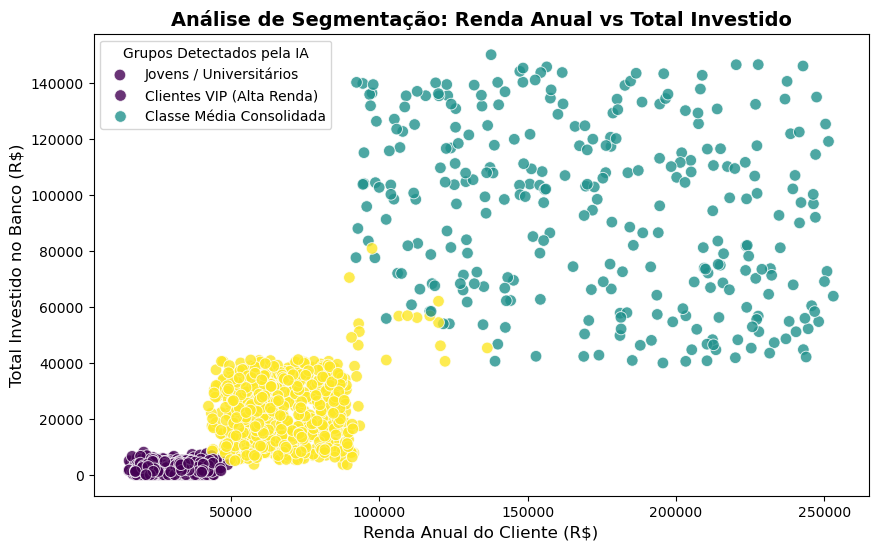

In [10]:
# ==============================================================================
# PROJETO 3: SEGMENTAÇÃO DE CLIENTES (MARKETING BANCÁRIO)
# ETAPA 3: GERAR O GRÁFICO VISUAL DOS GRUPOS PARA O DIRETOR DE MARKETING
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns

# Configurando o tamanho do gráfico na tela
plt.figure(figsize=(10, 6))

# Criamos um gráfico de dispersão (pontos) cruzando Renda e Investimento.
# O comando 'hue=grupo_cliente' diz para o Python pintar os pontos com cores 
# diferentes baseadas nos grupos que a Inteligência Artificial descobriu.
sns.scatterplot(
    x='renda_anual', 
    y='total_investido', 
    hue='grupo_cliente', 
    data=df_marketing, 
    palette='viridis', # Aplica um conjunto de cores moderno e bonito
    alpha=0.8,
    s=70 # Define o tamanho dos pontinhos no gráfico
)

# Colocamos títulos claros e profissionais para qualquer leigo entender
plt.title('Análise de Segmentação: Renda Anual vs Total Investido', fontsize=14, fontweight='bold')
plt.xlabel('Renda Anual do Cliente (R$)', fontsize=12)
plt.ylabel('Total Investido no Banco (R$)', fontsize=12)

# Customizamos as legendas para a apresentação ficar impecável
plt.legend(title='Grupos Detectados pela IA', labels=['Jovens / Universitários', 'Clientes VIP (Alta Renda)', 'Classe Média Consolidada'])

# Exibe o gráfico finalizado na tela
plt.show()